# Analysis and Forecasting of Electricity Prices (Germany, 2018–2025)
## II. Analysis and Modeling

**Importing the required libraries**

In [1]:
import pandas as pd
import numpy as np, random, os
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.signal import periodogram
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import ccf
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import skew, kurtosis, shapiro
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import holidays
from tabulate import tabulate

**Setting the visualization style**

In [2]:
def set_style():
    mpl.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Georgia'],
        'font.size': 12,

        'axes.titlesize': 12,
        'axes.labelsize': 12,
        'axes.labelcolor': '#444444',

        'axes.grid': True,
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,
        'grid.color': 'lightgray',
        'grid.alpha': 0.35,

        'figure.figsize': (10, 5),
        'lines.linewidth': 1.8,

        'legend.frameon': True,
        'legend.fontsize': 11,
        'legend.labelcolor': '#444444',

        'axes.edgecolor': '#444444',
        'axes.linewidth': 0.7,
        'xtick.color': '#444444',
        'ytick.color': '#444444',

        'axes.prop_cycle': mpl.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']),
    })

set_style()

### 1. Data

In [3]:
# Data from multiple sources (SMARD.de, Open-Meteo, Bundesnetzagentur), preprocessed and consolidated into a single dataset in the file Data.ipynb
# Period: October 1, 2018 – October 19, 2025
# Frequency: Weekly
df = pd.read_csv('Day-ahead Prices_2015_2025_Week.csv')

df['week_start'] = pd.to_datetime(df['week_start'], errors='coerce')
df = df.set_index('week_start').sort_index()

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 368 entries, 2018-10-01 to 2025-10-13
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   elec_price         368 non-null    float64
 1   nat_gas_price      368 non-null    float64
 2   wind_speed         368 non-null    float64
 3   sunshine_duration  368 non-null    float64
dtypes: float64(4)
memory usage: 14.4 KB


In [4]:
df.head()

,elec_price,nat_gas_price,wind_speed,sunshine_duration
week_start,,,,
2018-10-01,51.45,26.630,4.377025,51.380006
2018-10-08,54.53,26.860,3.620766,64.365325
2018-10-15,64.00,24.280,2.532683,58.445332
2018-10-22,47.71,24.285,5.586504,22.132139
2018-10-29,46.43,24.325,4.475013,29.297729


### 2. EDA, Model Identification

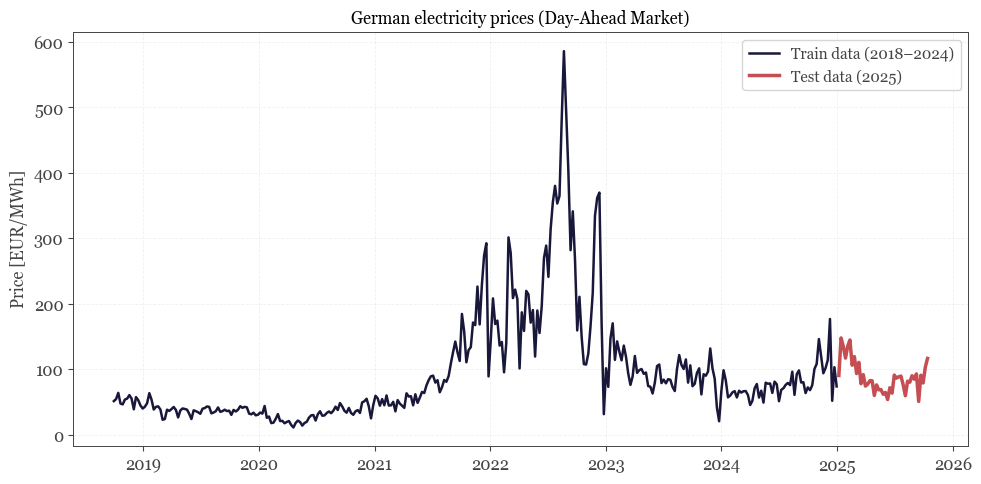

In [5]:
# Germany electricity prices (Day-Ahead Market)
data_odh_start = pd.Timestamp('2018-10-01')
data_odh_end =  pd.Timestamp('2024-12-31')
forecast_start = pd.Timestamp('2025-01-01')
forecast_end = pd.Timestamp('2025-10-20')

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(df.loc[data_odh_start:data_odh_end].index, 
        df.loc[data_odh_start:data_odh_end]['elec_price'],
        color='#19183a',
        label='Train data (2018–2024)')
ax.plot(
    df.loc[forecast_start:forecast_end].index,
    df.loc[forecast_start:forecast_end]['elec_price'],
    color='#C44E52',
    linewidth=2.5,
    label='Test data (2025)'
)

ax.set_title('German electricity prices (Day-Ahead Market)')
ax.set_ylabel('Price [EUR/MWh]')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [6]:
# Basic characteristics of electricity prices by period
df_1, df_2, df_3 = (
    df.loc['2018-10-01':'2021-09-27'],
    df.loc['2021-10-04':'2023-03-27'],
    df.loc['2023-04-03':]
)

periods = {
    'Q4 2018 – Q3 2021': df_1,
    'Q4 2021 – Q1 2023': df_2,
    'Q2 2023 – 2025': df_3,  # 2025-10-13
    'Full period': df
}

def compute_stats(series):
    log_returns = np.log(series).diff().dropna()
    return pd.Series({
        'Number of observations': series.count(),
        'Mean': series.mean(),
        'Standard deviation': series.std(),
        'Variance': series.var(),
        'Minimum': series.min(),
        'Maximum': series.max(),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt(),
        'Volatility': log_returns.std()
    })

stats = pd.DataFrame({
    name: compute_stats(df_['elec_price']) 
    for name, df_ in periods.items()
}).round(2)

print(tabulate(stats, headers='keys', tablefmt='github', floatfmt=".2f"))

|                        |   Q4 2018 – Q3 2021 |   Q4 2021 – Q1 2023 |   Q2 2023 – 2025 |   Full period |
|------------------------|---------------------|---------------------|------------------|---------------|
| Number of observations |              157.00 |               78.00 |           133.00 |        368.00 |
| Mean                   |               44.47 |              206.42 |            84.62 |         93.31 |
| Standard deviation     |               21.50 |              106.08 |            23.56 |         80.77 |
| Variance               |              462.07 |            11252.39 |           554.87 |       6523.85 |
| Minimum                |               11.19 |               31.50 |            20.69 |         11.19 |
| Maximum                |              142.36 |              585.92 |           176.85 |        585.92 |
| Skewness               |                1.88 |                1.24 |             0.81 |          2.55 |
| Kurtosis               |                4.91

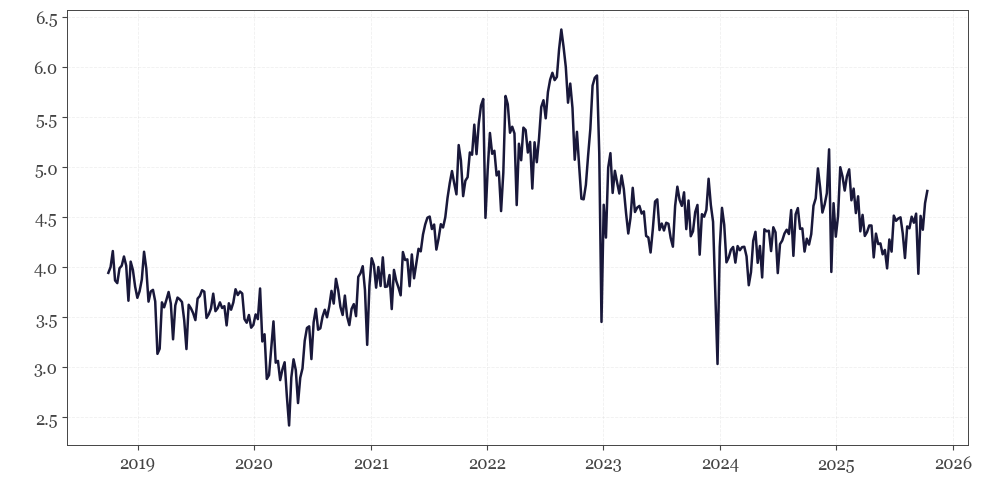

In [7]:
#Log-transformed electricity price time series
df['ln_el_price'] = np.log(df['elec_price'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['ln_el_price'], color='#19183a')
ax.set_ylabel(' ')
plt.tight_layout()
plt.show()

#### 2.1 Stationarity Tests: ADF, KPSS

In [8]:
# Testing the stationarity of the log-transformed electricity price time series
adf_test = adfuller(df['ln_el_price'], regression='ct', autolag='AIC')
kpss_test = kpss(df['ln_el_price'], regression='ct')

results_table = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Test statistic': [adf_test[0], kpss_test[0]],
    'p-value': [adf_test[1], kpss_test[1]],
    'Critical value (α = 0.05)': [adf_test[4]['5%'], kpss_test[3]['5%']]
}).round(3)

print(results_table.to_markdown(index=False))

| Test   |   Test statistic |   p-value |   Critical value (α = 0.05) |
|:-------|-----------------:|----------:|----------------------------:|
| ADF    |           -1.829 |     0.691 |                      -3.423 |
| KPSS   |            0.435 |     0.01  |                       0.146 |


/tmp/ipykernel_1353320/3354323291.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(df['ln_el_price'], regression='ct')


#### 2.2 ACF and PACF of the log-transformed time series

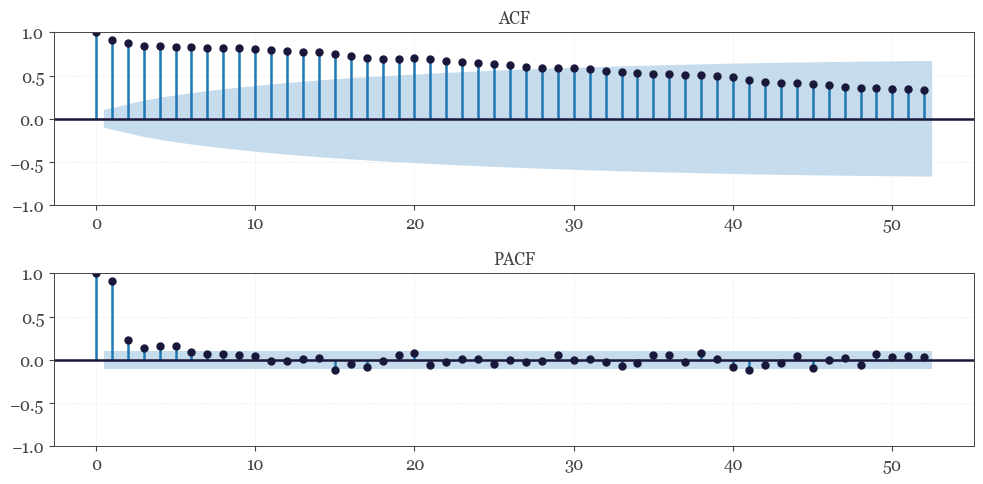

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(df['ln_el_price'], ax=axes[0], lags=52, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(df['ln_el_price'].dropna(), ax=axes[1], lags=52, method='ywm', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()

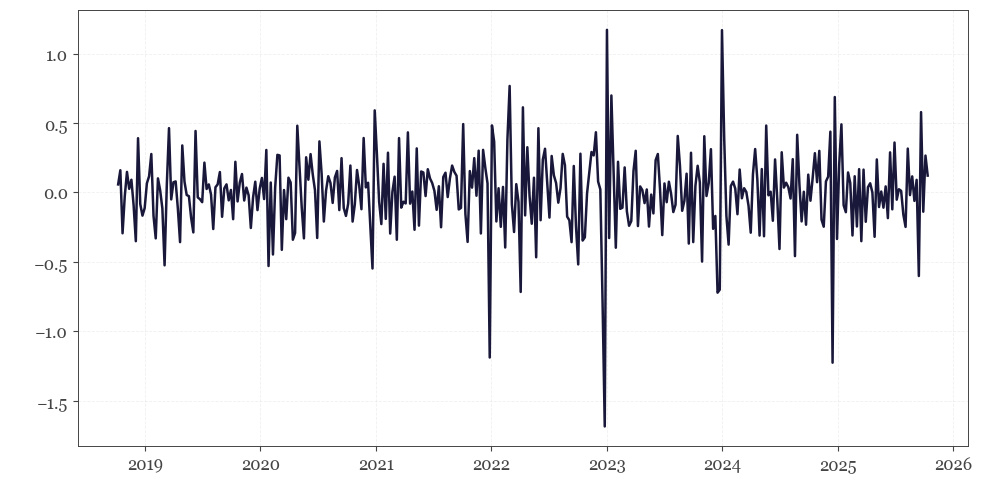

In [10]:
# First difference of the log-transformed electricity price
df['d_ln_el_price'] = df['ln_el_price'].diff()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['d_ln_el_price'], color='#19183a')
ax.set_ylabel(' ')
plt.tight_layout()
plt.show()

In [11]:
# Results of ADF and KPSS tests for the log-transformed electricity prices after first differencing
adf_test_2 = adfuller(df['d_ln_el_price'].dropna(), regression='c', autolag='AIC')
kpss_test_2 = kpss(df['d_ln_el_price'].dropna(), regression='c')

results_table_2 = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Test statistic': [adf_test_2[0], kpss_test_2[0]],
    'p-value': [adf_test_2[1], kpss_test_2[1]],
    'Critical value (α = 0.05)': [adf_test_2[4]['5%'], kpss_test_2[3]['5%']]
}).round(3)

print(results_table_2.to_markdown(index=False))

| Test   |   Test statistic |   p-value |   Critical value (α = 0.05) |
|:-------|-----------------:|----------:|----------------------------:|
| ADF    |          -11.279 |       0   |                      -2.87  |
| KPSS   |            0.086 |       0.1 |                       0.463 |


/tmp/ipykernel_1353320/3019792082.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test_2 = kpss(df['d_ln_el_price'].dropna(), regression='c')


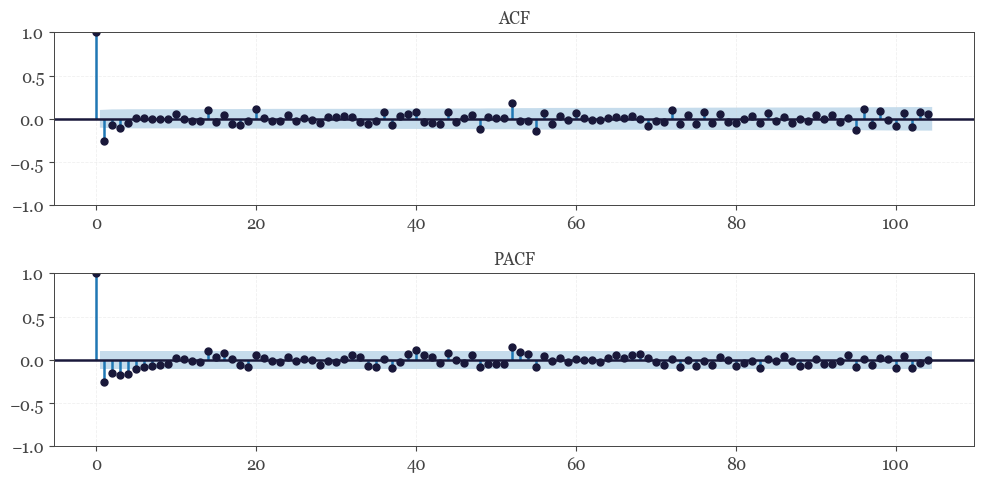

In [12]:
# ACF and PACF of the log-transformed electricity price time series after first differencing
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(df['d_ln_el_price'].dropna(), ax=axes[0], lags=104, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(df['d_ln_el_price'].dropna(), ax=axes[1], lags=104, method='ywm', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()

### 3. Modeling

In [13]:
df = df.asfreq('W-MON')

In [14]:
# Splitting the dataset into training and testing sets
y_train = df[:'2024-12-31']['ln_el_price']
y_test  = df['2025-01-01':]['ln_el_price']

In [15]:
y_test.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 41 entries, 2025-01-06 to 2025-10-13
Freq: W-MON
Series name: ln_el_price
Non-Null Count  Dtype  
--------------  -----  
41 non-null     float64
dtypes: float64(1)
memory usage: 656.0 bytes


#### 3.1 ARIMA(p,d,q)

In [16]:
# 1. ARIMA(0,1,0)
arima_1 = ARIMA(
    y_train, 
    order=(0,1,0),
).fit()

residuals_arima_1 = arima_1 .resid
print(arima_1.summary())

                               SARIMAX Results                                
Dep. Variable:            ln_el_price   No. Observations:                  327
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 -63.830
Date:                Mon, 06 Apr 2026   AIC                            129.660
Time:                        16:06:13   BIC                            133.447
Sample:                    10-01-2018   HQIC                           131.172
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0866      0.004     24.349      0.000       0.080       0.094
Ljung-Box (L1) (Q):                  19.02   Jarque-Bera (JB):               401.12
Prob(Q):                              0.00   Pr

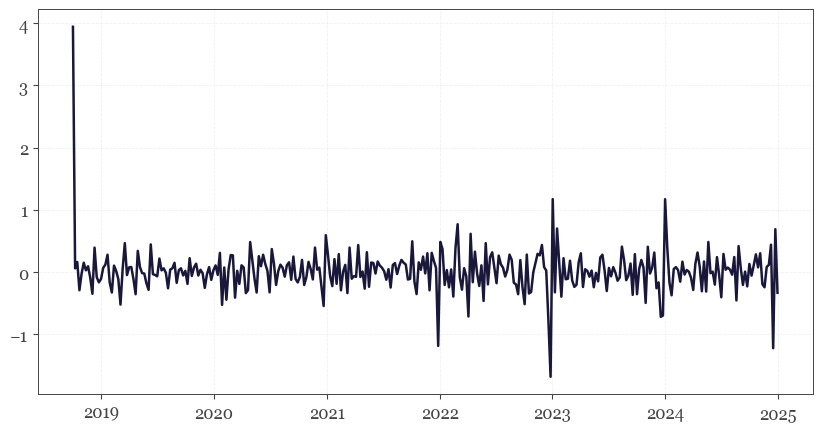

In [17]:
# Rezidua ARIMA(0,1,0)
plt.figure(figsize=(10, 5))
plt.plot(residuals_arima_1, color="#19183a")
plt.show()

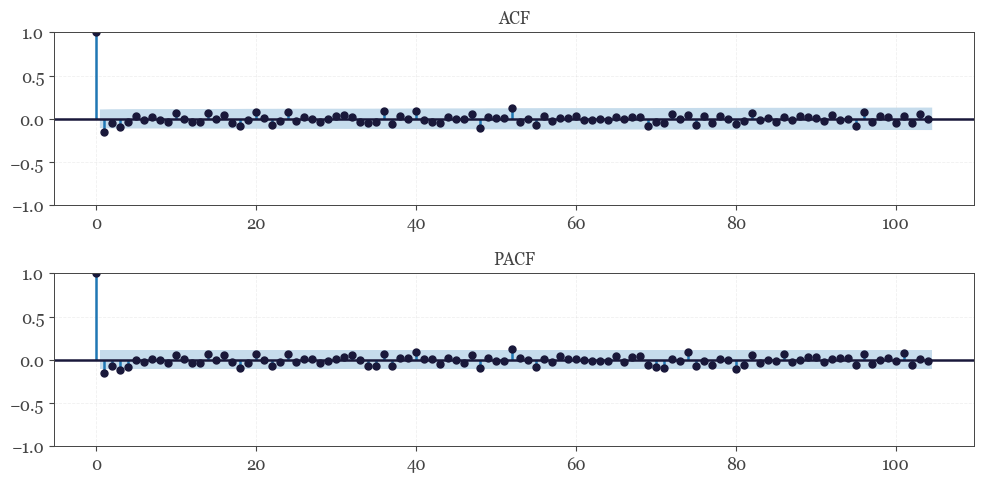

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(residuals_arima_1, ax=axes[0], lags=104, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(residuals_arima_1, ax=axes[1], lags=104, method='yw', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()

In [19]:
# 2. ARIMA(1,1,1)
arima_2 = ARIMA(
    y_train,
    order=(1,1,1)
).fit()

residuals_arima_2 = arima_2.resid
print(arima_2.summary())

                               SARIMAX Results                                
Dep. Variable:            ln_el_price   No. Observations:                  327
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -36.775
Date:                Mon, 06 Apr 2026   AIC                             79.551
Time:                        16:06:17   BIC                             90.912
Sample:                    10-01-2018   HQIC                            84.084
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4179      0.076      5.469      0.000       0.268       0.568
ma.L1         -0.8048      0.057    -14.233      0.000      -0.916      -0.694
sigma2         0.0733      0.003     22.444      0.0

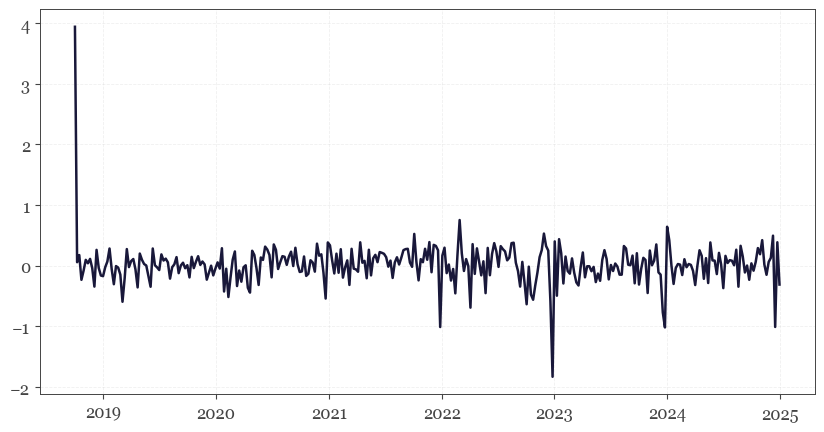

In [20]:
# Rezidua ARIMA(1,1,1)
plt.figure(figsize=(10, 5))
plt.plot(residuals_arima_2, color='#19183a')
plt.show()

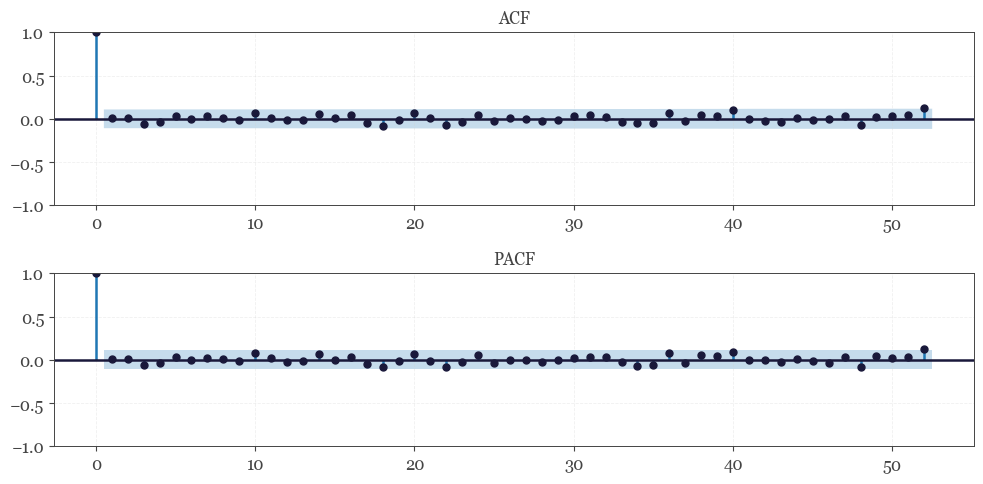

In [21]:
# Reziduální ACF a PACF modelu ARIMA(1,1,1)
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(residuals_arima_2, ax=axes[0], lags=52, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(residuals_arima_2, ax=axes[1], lags=52, method='yw', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()

#### 3.2 SARIMA(p,d,q) x (P,D,Q)s

In [22]:
# 3. SARIMA(1, 1, 1)(1, 0, 0, 52)
sarima_1 = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()

residuals_sarima_1 = sarima_1.resid
print(sarima_1.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         ln_el_price   No. Observations:                  327
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 52)   Log Likelihood                 -38.600
Date:                             Mon, 06 Apr 2026   AIC                             85.199
Time:                                     16:06:22   BIC                             99.637
Sample:                                 10-01-2018   HQIC                            90.995
                                      - 12-30-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3834      0.090      4.242      0.000       0.206       0.560
ma.L1         -0.7835      

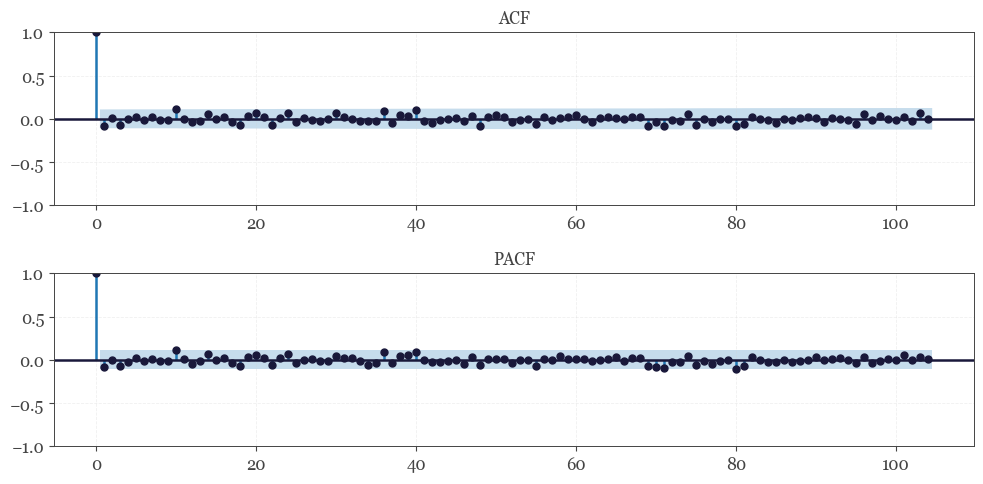

In [23]:
# Reziduální ACF a PACF modelu SARIMA(1, 1, 1)(1, 0, 0, 52)
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

plot_acf(residuals_sarima_1, ax=axes[0], lags=104, color='#19183a')
axes[0].set_title('ACF', color='#444444')

plot_pacf(residuals_sarima_1, ax=axes[1], lags=104, method='ywm', color='#19183a')
axes[1].set_title('PACF', color='#444444')

plt.tight_layout()
plt.show()

#### 3.3 SARIMAX(p,d,q) x (P,D,Q)s

In [24]:
# 3.3.1 Analysis of Explanatory Variables

In [25]:
df['crisis_dummy'] = (
    (df.index >= '2021-10-04') &
    (df.index <= '2023-03-27')
).astype(int)

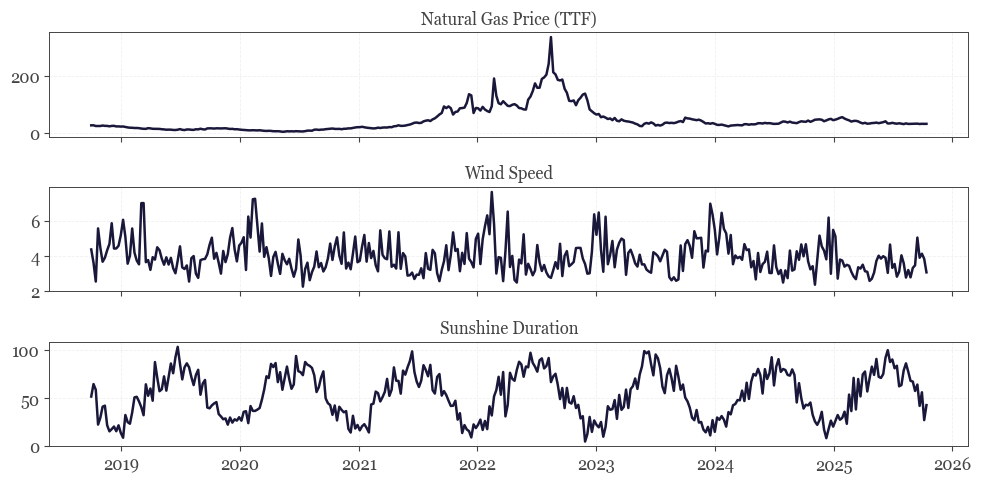

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

# 1. Natural gas price (TTF)
axes[0].plot(df['nat_gas_price'], color='#19183a')
axes[0].set_title('Natural Gas Price (TTF)', color='#444444')

# 2. Wind speed
axes[1].plot(df['wind_speed'], color='#19183a')
axes[1].set_title('Wind Speed', color='#444444')

# 3. Sunshine duration
axes[2].plot(df['sunshine_duration'], color='#19183a')
axes[2].set_title('Sunshine Duration', color='#444444')

plt.tight_layout()
plt.show()

In [27]:
# Log-transformed natural gas price (TTF)
df['ln_gas_price'] = np.log(df['nat_gas_price'])

In [28]:
adf_test_9 = adfuller(df['ln_gas_price'], regression='ct', autolag='AIC')
kpss_test_9 = kpss(df['ln_gas_price'], regression='ct')

results_table_9 = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Statistic': [adf_test_9[0], kpss_test_9[0]],
    'p-value': [adf_test_9[1], kpss_test_9[1]],
    'Critical Value (5%)': [adf_test_9[4]['5%'], kpss_test_9[3]['5%']]
}).round(3)

print(results_table_9.to_markdown(index=False))

| Test   |   Statistic |   p-value |   Critical Value (5%) |
|:-------|------------:|----------:|----------------------:|
| ADF    |      -1.245 |     0.901 |                -3.423 |
| KPSS   |       0.412 |     0.01  |                 0.146 |


/tmp/ipykernel_1353320/2853589741.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test_9 = kpss(df['ln_gas_price'], regression='ct')


In [29]:
# First diference of the log-transformed natural gas price (TTF)
df['d_ln_gas_price'] = df['ln_gas_price'].diff()

In [30]:
adf_test_9 = adfuller(df['d_ln_gas_price'].dropna(), regression='c', autolag='AIC')
kpss_test_9 = kpss(df['d_ln_gas_price'].dropna(), regression='c')

results_table_9 = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Statistika': [adf_test_9[0], kpss_test_9[0]],
    'p-hodnota': [adf_test_9[1], kpss_test_9[1]],
    'Kritická hodnota (5%)': [ adf_test_9[4]['5%'], kpss_test_9[3]['5%']]
}).round(3)

print(results_table_9.to_markdown(index=False))

| Test   |   Statistika |   p-hodnota |   Kritická hodnota (5%) |
|:-------|-------------:|------------:|------------------------:|
| ADF    |      -15.367 |         0   |                  -2.869 |
| KPSS   |        0.149 |         0.1 |                   0.463 |


/tmp/ipykernel_1353320/4029970173.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test_9 = kpss(df['d_ln_gas_price'].dropna(), regression='c')


In [31]:
# Transformed wind speed
df['wind_speed_3'] = df['wind_speed'] ** 3

In [32]:
adf_test_10 =  adfuller(df['wind_speed_3'], regression='ct', autolag='AIC')
kpss_test_10 = kpss(df['wind_speed_3'], regression='ct', nlags='auto')

results_table_10 = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Statistika': [adf_test_10[0], kpss_test_10[0]],
    'p-hodnota': [adf_test_10[1], kpss_test_10[1]],
    'Kritická hodnota (5%)': [adf_test_10[4]['5%'], kpss_test_10[3]['5%']]
}).round(3)

print(results_table_10.to_markdown(index=False))

| Test   |   Statistika |   p-hodnota |   Kritická hodnota (5%) |
|:-------|-------------:|------------:|------------------------:|
| ADF    |       -6.595 |         0   |                  -3.423 |
| KPSS   |        0.053 |         0.1 |                   0.146 |


/tmp/ipykernel_1353320/4016806364.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test_10 = kpss(df['wind_speed_3'], regression='ct', nlags='auto')


In [33]:
# Sunshine duration
adf_test_8 =  adfuller(df['sunshine_duration'], regression='ct', autolag='AIC')
kpss_test_8 = kpss(df['sunshine_duration'], regression='ct')

results_table_8 = pd.DataFrame({
    'Test': ['ADF', 'KPSS'],
    'Statistika': [adf_test_8[0], kpss_test_8[0]],
    'p-hodnota': [adf_test_8[1], kpss_test_8[1]],
    'Kritická hodnota (5%)': [adf_test_8[4]['5%'], kpss_test_8[3]['5%']]
}).round(3)

print(results_table_8.to_markdown(index=False))

| Test   |   Statistika |   p-hodnota |   Kritická hodnota (5%) |
|:-------|-------------:|------------:|------------------------:|
| ADF    |       -8.211 |         0   |                  -3.423 |
| KPSS   |        0.027 |         0.1 |                   0.146 |


/tmp/ipykernel_1353320/3261662775.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test_8 = kpss(df['sunshine_duration'], regression='ct')


In [34]:
df.head()

,elec_price,nat_gas_price,wind_speed,sunshine_duration,ln_el_price,d_ln_el_price,crisis_dummy,ln_gas_price,d_ln_gas_price,wind_speed_3
week_start,,,,,,,,,,
2018-10-01,51.45,26.630,4.377025,51.380006,3.940610,NaN,0,3.282038,NaN,83.856541
2018-10-08,54.53,26.860,3.620766,64.365325,3.998751,0.058141,0,3.290638,0.008600,47.468056
2018-10-15,64.00,24.280,2.532683,58.445332,4.158883,0.160132,0,3.189653,-0.100985,16.245851
2018-10-22,47.71,24.285,5.586504,22.132139,3.865141,-0.293742,0,3.189859,0.000206,174.349367
2018-10-29,46.43,24.325,4.475013,29.297729,3.837946,-0.027195,0,3.191505,0.001646,89.615443


In [35]:
df = df.dropna()

In [36]:
y_train = df[:'2024-12-31']['ln_el_price']
y_test  = df['2025-01-01':]['ln_el_price']

In [37]:
x_train1 = df.loc[:'2024-12-31', ['d_ln_gas_price']]
x_test1  = df.loc['2025-01-01':, ['d_ln_gas_price']]

In [38]:
x_train2 = df.loc[:'2024-12-31', ['d_ln_gas_price', 'wind_speed_3']]
x_test2  = df.loc['2025-01-01':, ['d_ln_gas_price', 'wind_speed_3']]

In [39]:
x_train3 = df.loc[:'2024-12-31', ['d_ln_gas_price', 'wind_speed_3', 'sunshine_duration']]
x_test3  = df.loc['2025-01-01':, ['d_ln_gas_price', 'wind_speed_3', 'sunshine_duration']]

In [40]:
x_train4 = df.loc[:'2024-12-31', ['d_ln_gas_price', 'wind_speed_3', 'sunshine_duration', 'crisis_dummy']]
x_test4  = df.loc['2025-01-01':, ['d_ln_gas_price', 'wind_speed_3', 'sunshine_duration', 'crisis_dummy']]

In [41]:
# 4. SARIMAX(1,1,1)(1,0,0)
sarimax_1 = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    exog=x_train1,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
r_sarimax = sarimax_1.resid
print(sarimax_1.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         ln_el_price   No. Observations:                  326
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 52)   Log Likelihood                 -31.553
Date:                             Mon, 06 Apr 2026   AIC                             73.105
Time:                                     16:27:25   BIC                             91.134
Sample:                                 10-08-2018   HQIC                            80.343
                                      - 12-30-2024                                         
Covariance Type:                               opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
d_ln_gas_price    -0.4078      0.092     -4.445      0.000      -0.588      -0.228
ar.L1          

In [42]:
# 5. SARIMAX(1,1,1)(1,0,0)
sarimax_2 = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    exog=x_train2,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
r_sarimax_2 = sarimax_2.resid
print(sarimax_2.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         ln_el_price   No. Observations:                  326
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 52)   Log Likelihood                  70.638
Date:                             Mon, 06 Apr 2026   AIC                           -129.276
Time:                                     16:27:48   BIC                           -107.641
Sample:                                 10-08-2018   HQIC                          -120.590
                                      - 12-30-2024                                         
Covariance Type:                               opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
d_ln_gas_price    -0.3153      0.053     -5.970      0.000      -0.419      -0.212
wind_speed_3   

In [43]:
# 6. SARIMAX(1,1,1)(1,0,0)
sarimax_3 = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    exog=x_train3,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

r_sarimax_3 = sarimax_3.resid
print(sarimax_3.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         ln_el_price   No. Observations:                  326
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 52)   Log Likelihood                  74.529
Date:                             Mon, 06 Apr 2026   AIC                           -135.058
Time:                                     16:28:11   BIC                           -109.817
Sample:                                 10-08-2018   HQIC                          -124.925
                                      - 12-30-2024                                         
Covariance Type:                               opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
d_ln_gas_price       -0.3053      0.054     -5.704      0.000      -0.410      -0.200
wind_s

In [44]:
# 7. SARIMAX(1,1,1)(1,0,0)
sarimax_4 = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    exog=x_train4,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

r_sarimax_4 = sarimax_4.resid
print(sarimax_4.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         ln_el_price   No. Observations:                  326
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 52)   Log Likelihood                  75.480
Date:                             Mon, 06 Apr 2026   AIC                           -134.959
Time:                                     16:28:36   BIC                           -106.113
Sample:                                 10-08-2018   HQIC                          -123.378
                                      - 12-30-2024                                         
Covariance Type:                               opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
d_ln_gas_price       -0.3032      0.055     -5.556      0.000      -0.410      -0.196
wind_s

In [45]:
# 8. SARIMAX(0,1,1)(1,0,0)
sarimax_5 = SARIMAX(
    y_train,
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 52),
    exog=x_train3,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()
r_sarimax_5 = sarimax_5.resid
print(sarimax_5.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         ln_el_price   No. Observations:                  326
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 52)   Log Likelihood                  75.435
Date:                             Mon, 06 Apr 2026   AIC                           -138.871
Time:                                     16:29:49   BIC                           -117.214
Sample:                                 10-08-2018   HQIC                          -130.177
                                      - 12-30-2024                                         
Covariance Type:                               opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
d_ln_gas_price       -0.3054      0.052     -5.824      0.000      -0.408      -0.203
wind_s

### 4. Forecasting

In [46]:
# ARIMA(1,1,1)
forecast_arima_2 = arima_2.get_forecast(steps=len(y_test))
pred1 = forecast_arima_2.predicted_mean
conf1 = forecast_arima_2.conf_int()

In [47]:
# SARIMA(1,1,1)(1,0,0)
forecast_sarima_1 = sarima_1.get_forecast(steps=len(y_test))
pred2 = forecast_sarima_1.predicted_mean
conf2 = forecast_sarima_1.conf_int()

In [48]:
# SARIMAX(1,1,1)(1,0,0)
forecast_sarimax_1 = sarimax_2.get_forecast(steps=len(y_test), exog=x_test2)
pred3 = forecast_sarimax_1.predicted_mean
conf3 = forecast_sarimax_1.conf_int()

In [49]:
# SARIMAX(0,1,1)(1,0,0)
forecast_sarimax_2 = sarimax_5.get_forecast(steps=len(y_test), exog=x_test3)
pred4 = forecast_sarimax_2.predicted_mean
conf4 = forecast_sarimax_2.conf_int()

In [50]:
forecast_price1 = np.exp(pred1)
forecast_price2 = np.exp(pred2)
forecast_price3 = np.exp(pred3)
forecast_price4 = np.exp(pred4)

In [52]:
# Splitting the dataset into training and testing sets
y_train = df[:'2024-12-31']['elec_price']
y_test  = df['2025-01-01':]['elec_price']

In [53]:
# Function for calculating forecast accuracy metrics
def forecast_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

In [54]:
arima2_metrics = forecast_metrics(y_test, forecast_price1)
print(arima2_metrics)

{'RMSE': np.float64(23.956428555959768), 'MAE': 18.34484373745597, 'MAPE': np.float64(21.552861725772765)}


In [56]:
sarima1_metrics = forecast_metrics(y_test, forecast_price2)
print(sarima1_metrics)

{'RMSE': np.float64(24.60347302292146), 'MAE': 19.609238665554617, 'MAPE': np.float64(23.471691654195382)}


In [57]:
sarimax1_metrics = forecast_metrics(y_test, forecast_price3)
print(sarimax1_metrics)

{'RMSE': np.float64(24.398221118679466), 'MAE': 21.585022232269857, 'MAPE': np.float64(27.67809243107103)}


In [58]:
sarimax2_metrics = forecast_metrics(y_test, forecast_price4)
print(sarimax2_metrics)

{'RMSE': np.float64(17.503154239037165), 'MAE': 14.923144192985546, 'MAPE': np.float64(18.213271525414513)}


### 5. Results

In [59]:
comparison_df = pd.DataFrame([
    {'Model': 'ARIMA(1,1,1)', 'RMSE': arima2_metrics['RMSE'], 'MAE': arima2_metrics['MAE'], 'MAPE': arima2_metrics['MAPE']},
    {'Model': 'SARIMA(1,1,1)(1,0,0)', 'RMSE': sarima1_metrics['RMSE'], 'MAE': sarima1_metrics['MAE'], 'MAPE': sarima1_metrics['MAPE']},
    {'Model': 'SARIMAX(1,1,1)(1,0,0)', 'RMSE': sarimax1_metrics['RMSE'], 'MAE': sarimax1_metrics['MAE'], 'MAPE': sarimax1_metrics['MAPE']},
    {'Model': 'SARIMAX(0,1,1)(1,0,0)', 'RMSE': sarimax2_metrics['RMSE'], 'MAE': sarimax2_metrics['MAE'], 'MAPE': sarimax2_metrics['MAPE']}
])
print(comparison_df)

                   Model       RMSE        MAE       MAPE
0           ARIMA(1,1,1)  23.956429  18.344844  21.552862
1   SARIMA(1,1,1)(1,0,0)  24.603473  19.609239  23.471692
2  SARIMAX(1,1,1)(1,0,0)  24.398221  21.585022  27.678092
3  SARIMAX(0,1,1)(1,0,0)  17.503154  14.923144  18.213272


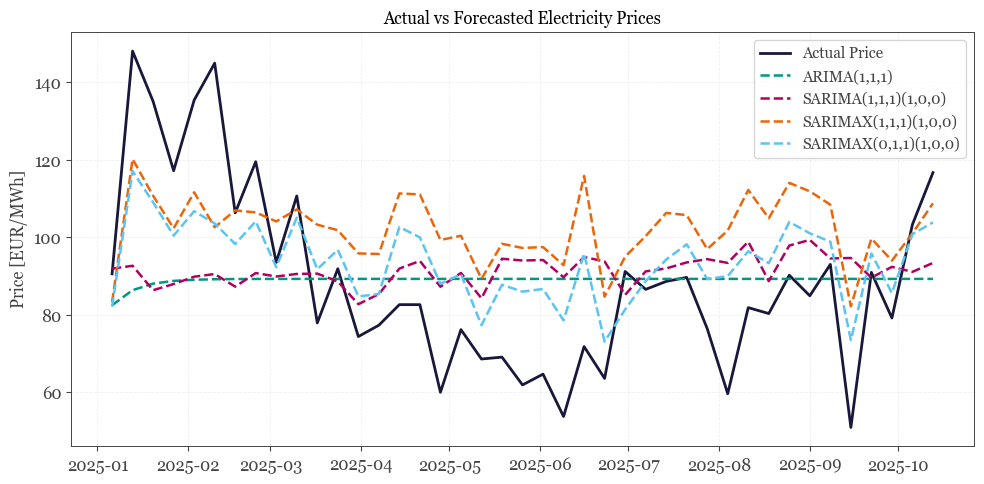

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.index, y_test, label='Actual Price', color='#19183a', linewidth=2)
plt.plot(y_test.index, forecast_price1, label='ARIMA(1,1,1)', color='#009881', linestyle='--')
plt.plot(y_test.index, forecast_price2, label='SARIMA(1,1,1)(1,0,0)', color='#b10062', linestyle='--')
plt.plot(y_test.index, forecast_price3, label='SARIMAX(1,1,1)(1,0,0)', color='#eb6608', linestyle='--')
plt.plot(y_test.index, forecast_price4, label='SARIMAX(0,1,1)(1,0,0)', color='#5bc4f1', linestyle='--')

plt.title('Actual vs Forecasted Electricity Prices')
plt.ylabel('Price [EUR/MWh]')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()